## **MILESTONE 1** 

 
========================================================   
#### **Identifikasi pemain berpengalaman yang Undervalued untuk Klub Papan Tengah**

 Nama       : Muhammad Cesar Rivaldo

 Batch      : HCK- 042

  #### Anda adalah seorang Sport Director di sebuah klub papan tengah di Eropa dengan budget transfer terbatas. Anda perlu menemukan pemain berpengalaman yang masih produktif namun harganya "masuk akal", agar klub bisa memperkuat tim secara efisien tanpa bersaing budget dengan klub-klub elit

=========================================================

### **PROBLEM STATEMENT DAN DATASET DESKRIPSI**



#### **Latar Belakang**
Klub papan tengah tidak bisa bersaing dengan budget klub elit lainnya, sehingga strategi rekrutmen harus efisien. Market Value di `Transfermarkt` cenderung bias ke usia muda, sehingga pemain berusia 28 tahun ke atas sering mengalami penurunan _value_ meski output di lapangan masih stabil. Di sinilah celahnya : pemain berpengalaman yang harganya turun karena faktor usia, bukan karena performanya turun. 

#### **Problem Statement**
Peran sebagai sport director klub papan tengah yang tengah mengidentifikasi 10-15 pemain berpengalaman (usia >= 28 tahun) di 5 liga top Eropa yang _Undervalued_, memiliki rasio performa terhadap market value terbaik, untuk dijadikan shortlist rekrutmen. 

**SPECIFIC :** Fokus pada rekrutmen pemain _undervalue_ (usia >= 28 tahun) di 5 liga top Eropa 

**MEASURABLE :** _undervalue_ = rasio value-for-money = total kontribusi (gol + asist)/market value. singkatnya, pemain yang performanya di atas median tetapi market valuenya tidak di bawah median

**ACHIVEABLE :** Bukan mencari pemain di seluruh dunia tapi hanya 5 liga top Eropa. 

**RELEVANT :** Membantu klub papan tengah yang terbatas budget serta mendukung keputusan pembelian pemain berbasis data. bukan feeling.

**TIME-BOUND :** Ditargetkan rampung sebelum transfer window musim panas (ausgust - sept) dibuka.

#### **Breaking Down the Problem**

Pertanyaan yang akan dijawab lewat visualisasi data dan analisis statistik : 

**Visualisasi :**
1. Bagimana pola market value terhadap usia pemain?
2. di liga dan posisi mana value rata-rata paling **"murah"**?
3. Sebaran pemain dengan output tinggi (gol + assist / menit) tapi value rendah?
4. Siapa top 10-15 pemain berdasarkan rasio value-for-money?

**Statistik Deskriptif :**

5. Bagaimana sebaran market value pemain berpengalaman (`mean`, `median`, `std`, `outlier`)?

**Statistik Inferensial :**

6. Apakah pemain >= 28 tahun dihargai signifikan lebih murah dibanding pemain < 28 tahun? (two-sample t-test) 


#### Data Source

[Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores) (Kaggle, oleh davidcariboo)

## Data Loading 

In [2]:
import pandas as pd 
import numpy as np

players = pd.read_csv('players.csv') # Load Data Pemain
valuations = pd.read_csv('player_valuations.csv') # Load Data Player Valuation
appearances = pd.read_csv('appearances.csv') # Load Data Penampilan Player
competitions = pd.read_csv('competitions.csv') # Load Data Kompetisi

# Cek Ukuran tiap tabel (baris dan kolom)
print('players :', players.shape)
print('valuation:', valuations.shape)
print('appearances:', appearances.shape)
print('competition:', competitions.shape 
      )


players : (48351, 26)
valuation: (662998, 6)
appearances: (1888125, 13)
competition: (65, 11)


In [4]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48351 entries, 0 to 48350
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             48351 non-null  int64  
 1   first_name                            45227 non-null  object 
 2   last_name                             48351 non-null  object 
 3   name                                  48351 non-null  object 
 4   last_season                           48351 non-null  int64  
 5   current_club_id                       48351 non-null  int64  
 6   player_code                           48351 non-null  object 
 7   country_of_birth                      43057 non-null  object 
 8   city_of_birth                         43335 non-null  object 
 9   country_of_citizenship                48080 non-null  object 
 10  date_of_birth                         48302 non-null  object 
 11  sub_position   

**INSIGHT:** Data Players berisi puluhan ribu pemain dari banyak liga, termasuk pemain muda akademi dan juga pemain yang sudah tidak aktif (pensiun). Pada tahap selanjutnya data akan dipersempit ke pemain aktif di 5 Liga top Eropa.

## Data Cleaning and Merge Data

#### 1. Menghitung Umur Pemain 

In [ ]:

# Ubah kolom tanggal lahir jadi umur
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')

# Tanggal acuan umur (hari ini)
hari_ini = pd.Timestamp('today')

# Umur = selisih hari dari lahir ke hari ini, di bagi setahun, dan di bulatkan 
players['age'] = ((hari_ini - players['date_of_birth']).dt.days / 365.25).round()

players[['name', 'date_of_birth', 'age']].head()

,name,date_of_birth,age
0,Miroslav Klose,1978-06-09,48.0
1,Roman Weidenfeller,1980-08-06,46.0
2,Dimitar Berbatov,1981-01-30,45.0
3,Lúcio,1978-05-08,48.0
4,Tom Starke,1981-03-18,45.0


### 2. Filter Liga dan Buang pemain Non-Aktif

In [ ]:
# Kode 5 Liga top Eropa dari dataset 
liga_top = ['GB1', 'ES1', 'L1', 'IT1', 'FR1']

# cari musim terbaru dan masukan semua datanya 
musim_terbaru = players['last_season'].max()

#ambil pemain yang masih aktif, minimal di musim sebelumnya 
players_top = players[
    (players['current_club_domestic_competition_id'].isin(liga_top)) &
    (players['last_season'] >= musim_terbaru - 1)
].copy()

# Ubah kode menjadi nama Liga
nama_liga = {
    'GB1': 'Premier League',
    'ES1': 'LaLiga',
    'L1': 'Bundesliga',
    'IT1': 'Serie A',
    'FR1': 'Ligue 1'
}
players_top['league'] = players_top['current_club_domestic_competition_id'].map(nama_liga)

print('Musim terbaru :', musim_terbaru)
print('Sebelum filter:', players.shape)
print('Sesudah filter:', players_top.shape)

Musim terbaru : 2025
Sebelum filter: (48351, 27)
Sesudah filter: (3911, 28)


**INSIGHT:** Data sudah menyusut drastis menjadi pemain aktif di 5 liga top. pemain pensiun dan non-aktif sudah terbuang karena syarat minimal `last_season` 

### 3. Menggabungkan Data Performa (2 musim terakhir)

In [ ]:

# Ubah kolom tanggal di appearances jadi format tanggal
appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')

# ambil hanya 2 musim terkahir
tanggal_terakhir = appearances['date'].max()
batas = tanggal_terakhir - pd.DateOffset(years=2)
appearances_baru = appearances[appearances['date'] >= batas].copy()

# jumlahkan performa tiap pemain
performa = appearances_baru.groupby('player_id').agg(
    total_gol=('goals', 'sum'),
    total_assist=('assists', 'sum'),
    total_menit=('minutes_played', 'sum'),
    jumlah_tampil=('game_id', 'count')
).reset_index()

# Tempelkan performa ke tebel pemain (left join agar semua pemain top tetep ada)
df = players_top.merge(performa, on='player_id', how='left')

# pemain tanpa catatan tampil 2 musim terakhir diisi 0
df[['total_gol', 'total_assist', 'total_menit', 'jumlah_tampil']] = \
    df[['total_gol', 'total_assist', 'total_menit', 'jumlah_tampil']].fillna(0)

df[['name', 'age', 'league', 'total_gol', 'total_assist', 'total_menit']]


,name,age,league,total_gol,total_assist,total_menit
0,James Milner,40.0,Premier League,1.0,1.0,1119.0
1,Jonas Hofmann,34.0,Bundesliga,6.0,5.0,1984.0
2,Pepe Reina,44.0,Serie A,0.0,0.0,1215.0
3,Ludovic Butelle,43.0,Ligue 1,0.0,0.0,0.0
4,Daley Blind,36.0,LaLiga,0.0,3.0,5953.0
...,...,...,...,...,...,...
3906,Samu Becerra,20.0,LaLiga,0.0,0.0,99.0
3907,Yan Diomande,20.0,Bundesliga,16.0,11.0,3618.0
3908,Josito González,20.0,LaLiga,0.0,0.0,10.0
3909,Carlos Macià,18.0,LaLiga,0.0,0.0,134.0


**INSIGHT:** Data setiap pemain sekarang punya total 2 musim terakhir performa bersama klub sebelumnya 

### 4. Analysis Column (Contribute and Value for Money)

In [12]:
df['kontribusi'] = df['total_gol'] + df['total_assist']

df['value_juta'] = df['market_value_in_eur'] / 1_000_000

df['value_for_money'] = df['kontribusi'] / df['value_juta']

df[['name', 'kontribusi', 'value_juta', 'value_for_money']]

,name,kontribusi,value_juta,value_for_money
0,James Milner,2.0,0.500,4.000000
1,Jonas Hofmann,11.0,1.500,7.333333
2,Pepe Reina,0.0,0.600,0.000000
3,Ludovic Butelle,0.0,0.100,0.000000
4,Daley Blind,3.0,1.200,2.500000
...,...,...,...,...
3906,Samu Becerra,0.0,0.300,0.000000
3907,Yan Diomande,27.0,90.000,0.300000
3908,Josito González,0.0,0.025,0.000000
3909,Carlos Macià,0.0,3.000,0.000000


In [14]:
# pilih kolom yang dipakai saja
kolom = ['player_id', 'name', 'age', 'position', 'sub_position', 'current_club_name',
         'league', 'market_value_in_eur', 'value_juta', 'total_gol', 'total_assist',
         'kontribusi', 'total_menit', 'jumlah_tampil', 'value_for_money']
df = df[kolom]

# buang pemain tanpa market value (tidak bisa dinilai murah/mahal)
df = df[df['market_value_in_eur'] > 0]

# buang pemain yang tidak pernah tampil 2 musim terakhir (efektif non-aktif)
df = df[df['total_menit'] > 0]

# buang baris dengan umur kosong
df = df.dropna(subset=['age'])

print('Ukuran data siap analisis:', df.shape)
df.info()

Ukuran data siap analisis: (3197, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 3197 entries, 0 to 3910
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            3197 non-null   int64  
 1   name                 3197 non-null   object 
 2   age                  3197 non-null   float64
 3   position             3197 non-null   object 
 4   sub_position         3197 non-null   object 
 5   current_club_name    3197 non-null   object 
 6   league               3197 non-null   object 
 7   market_value_in_eur  3197 non-null   float64
 8   value_juta           3197 non-null   float64
 9   total_gol            3197 non-null   float64
 10  total_assist         3197 non-null   float64
 11  kontribusi           3197 non-null   float64
 12  total_menit          3197 non-null   float64
 13  jumlah_tampil        3197 non-null   float64
 14  value_for_money      3197 non-null   float64
dtypes: fl

**INISGHT:** Data sudah bersih, hanya pemain aktif di 5 liga top, lengkap dengan umur, performa, market value, dan rasio value-for-money. siap dieksplorasi. 

## Exploration and Analysis

#### 1. Bagaimana pola market value terhadap usia pemain??

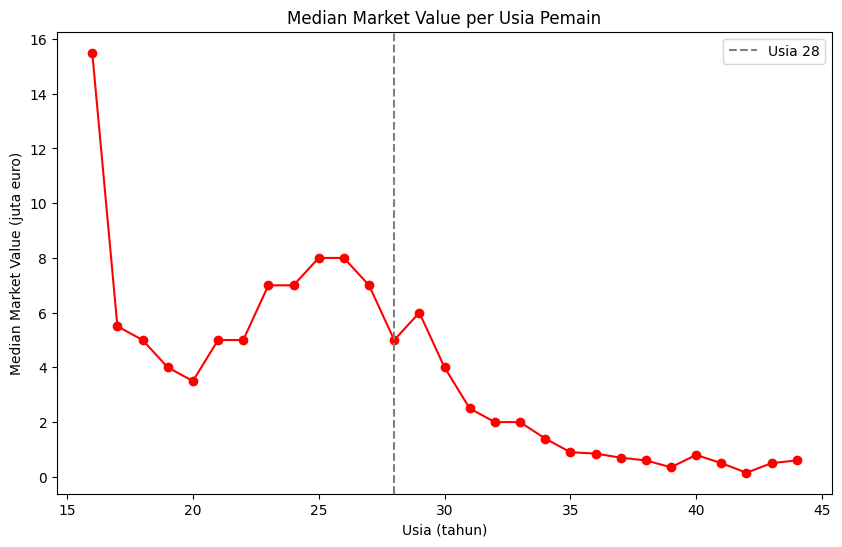

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns 

# garis median value per umur, biar pola turun-naiknya jelas
median_per_umur = df.groupby('age')['value_juta'].median()

median_per_umur = df.groupby('age')['value_juta'].median()

plt.figure(figsize=(10, 6))
plt.plot(median_per_umur.index, median_per_umur.values, color='red', marker='o')

# garis bantu di usia 28 sebagai penanda batas "berpengalaman"
plt.axvline(28, color='gray', linestyle='--', label='Usia 28')

plt.title('Median Market Value per Usia Pemain')
plt.xlabel('Usia (tahun)')
plt.ylabel('Median Market Value (juta euro)')
plt.legend()
plt.show()

**INSIGHT:** Market value memuncak di awal 20-an lalu menurun setelah pemain meranjak usia 28. dari sini sudah terkonfirmasi bahwa, pemain yang nilainya turun karena usianya ikut menurun. 

#### 2. Di Liga dan posisi mana value Rata-rata paling murah?

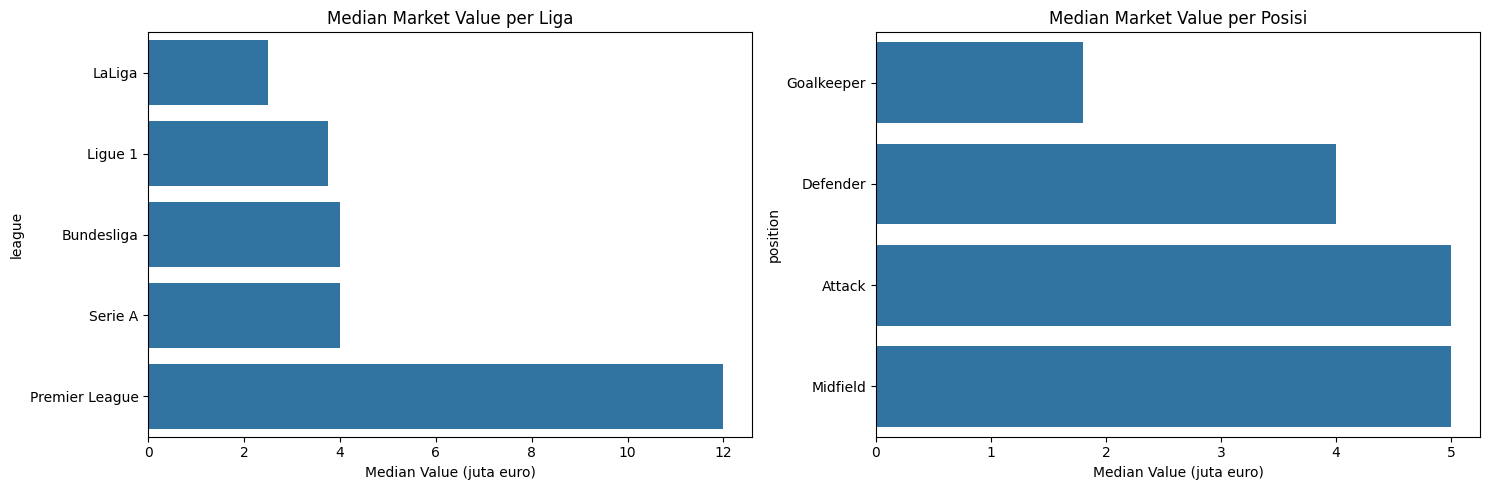

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# median value per liga
liga_value = df.groupby('league')['value_juta'].median().sort_values()
sns.barplot(x=liga_value.values, y=liga_value.index, ax=axes[0])
axes[0].set_title('Median Market Value per Liga')
axes[0].set_xlabel('Median Value (juta euro)')

# median value per posisi
posisi_value = df.groupby('position')['value_juta'].median().sort_values()
sns.barplot(x=posisi_value.values, y=posisi_value.index, ax=axes[1])
axes[1].set_title('Median Market Value per Posisi')
axes[1].set_xlabel('Median Value (juta euro)')

plt.tight_layout()
plt.show()

**INSIGHT:** La Liga memiliki median value terendah, dan posisi goalkeeper paling murah. Ini merukapan petunjuk dimana Sport Director sebaiknya berburu pemain. namun, harga market value di tiap posisi nya hanya berbeda tipis.

#### 3. Sebaran pemain > 28 Tahun dengan output tinggi

/var/folders/yb/3dwx78xx2vg2rb00_2l39jlw0000gn/T/ipykernel_57427/1824780523.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kontribusi_tier = df_28.groupby('tier_harga')['kontribusi'].mean()


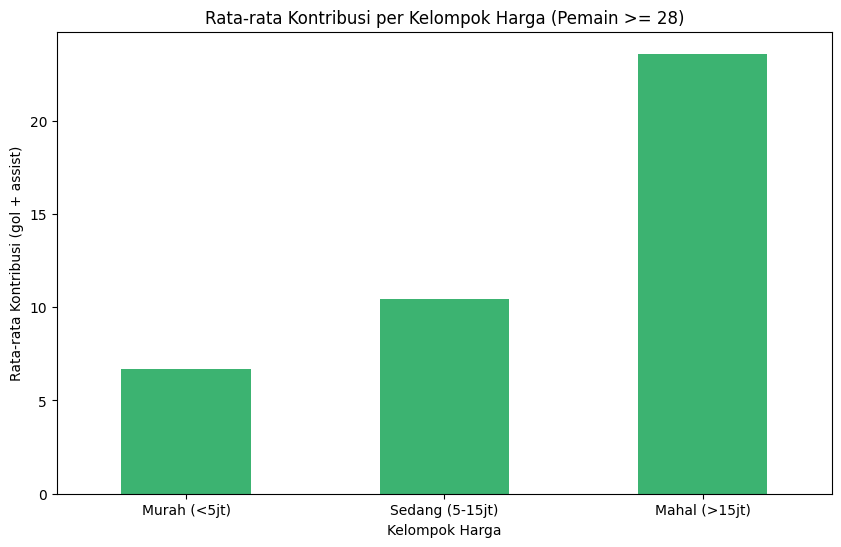

In [53]:
df_28 = df[(df['age'] >= 28) & (df['total_menit'] >= 1500)].copy()

# bagi pemain berpengalaman ke 3 kelompok harga
df_28['tier_harga'] = pd.cut(df_28['value_juta'],
                             bins=[0, 5, 15, df_28['value_juta'].max()],
                             labels=['Murah (<5jt)', 'Sedang (5-15jt)', 'Mahal (>15jt)'])

# hitung rata-rata kontribusi per kelompok harga
kontribusi_tier = df_28.groupby('tier_harga')['kontribusi'].mean()

kontribusi_tier.plot(kind='bar', figsize=(10, 6), color='mediumseagreen',
                     title='Rata-rata Kontribusi per Kelompok Harga (Pemain >= 28)')
plt.xlabel('Kelompok Harga'); plt.ylabel('Rata-rata Kontribusi (gol + assist)')
plt.xticks(rotation=0)
plt.show()

**INSIGHT:** Rata-rata kontribusi kelompok Murah lebih rendah daripada kelompok Mahal. Artinya
secara umum pasar transfer cukup rasional: makin mahal pemain, rata-rata kontribusinya
memang makin tinggi "ada harga, ada barang". Tetapi ini hanya gambaran rata-rata
kelompok. Pemain undervalued bukan dilihat dari rata-rata, melainkan dari individu di
kelompok murah yang kontribusinya jauh di atas harga yang seharusnya. Justru karena
pasar broadly rasional, pemain pengecualian inilah yang berharga, dan akan kita
temukan namanya lewat rasio value-for-money pada pertanyaan berikutnya.

#### 4. 15 Pemain berdasarkan rasio value-for-money

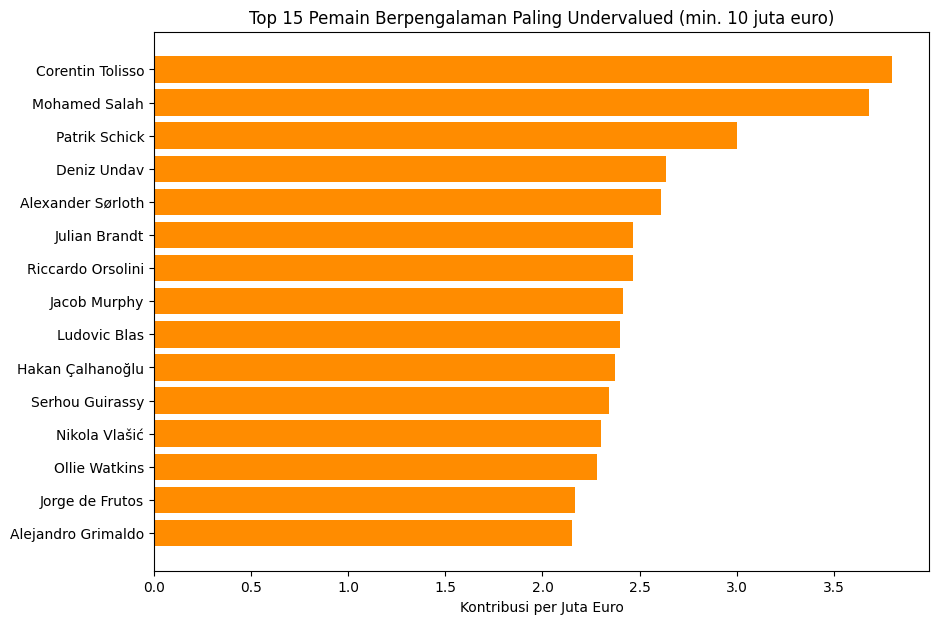

,name,age,position,league,current_club_name,value_juta,kontribusi,value_for_money
458,Corentin Tolisso,32.0,Midfield,Ligue 1,Olympique Lyonnais,10.0,38.0,3.800000
333,Mohamed Salah,34.0,Attack,Premier League,Liverpool Football Club,22.0,81.0,3.681818
648,Patrik Schick,30.0,Attack,Bundesliga,Bayer 04 Leverkusen Fußball,18.0,54.0,3.000000
1041,Deniz Undav,30.0,Attack,Bundesliga,Verein für Bewegungsspiele Stuttgart 1893,22.0,58.0,2.636364
626,Alexander Sørloth,31.0,Attack,LaLiga,Club Atlético de Madrid S.A.D.,18.0,47.0,2.611111
448,Julian Brandt,30.0,Midfield,Bundesliga,Borussia Dortmund,15.0,37.0,2.466667
1210,Riccardo Orsolini,29.0,Attack,Serie A,Bologna Football Club 1909,15.0,37.0,2.466667
512,Jacob Murphy,31.0,Attack,Premier League,Newcastle United Football Club,12.0,29.0,2.416667
837,Ludovic Blas,28.0,Midfield,Ligue 1,Stade Rennais Football Club,10.0,24.0,2.400000
259,Hakan Çalhanoğlu,32.0,Midfield,Serie A,Football Club Internazionale Milano S.p.A.,16.0,38.0,2.375000


In [85]:
top15 = df_28[df_28['value_juta'] >= 10].sort_values('value_for_money', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15['name'], top15['value_for_money'], color='darkorange')
plt.gca().invert_yaxis()
plt.title('Top 15 Pemain Berpengalaman Paling Undervalued (min. 10 juta euro)')
plt.xlabel('Kontribusi per Juta Euro')
plt.show()

top15[['name', 'age', 'position', 'league', 'current_club_name',
       'value_juta', 'kontribusi', 'value_for_money']]

**INSIGHT:** Dengan set lantai harga minimal 10 juta euro, shortlist tidak lagi berisi pemain bernilai sangat kecil, melainkan pemain berpengalaman yang kualitasnya sudah terbukti namun harganya terdiskon oleh faktor usia ke kisaran yang masih terjangkau. Pemain di puncak dengan nama `Corentin Tolisso` dari Ligue 1 (Perancis) yang bermain bersama `Olymique Lyon`, memberi sekitar 38 kontribusi perjuta euro. Mayoritas nama di shortlist berusia 29-34 tahun dan dominan bermain di posisi attack dan juga midfield. Daftar ini bukan sekedar "pemain murah" melainkan "pemain mapan dengan harga wajar". justru target pemain seperti ini merupakan target realistis untuk klub papan tengah yang menginginkan dampak yang instan.

#### 5. Statistik Deskriptif : Bagaimana sebaran market value pemain berpengalaman?

count    899.000000
mean       8.786707
std       13.760230
min        0.100000
25%        1.800000
50%        4.000000
75%       10.000000
max      180.000000
Name: value_juta, dtype: float64


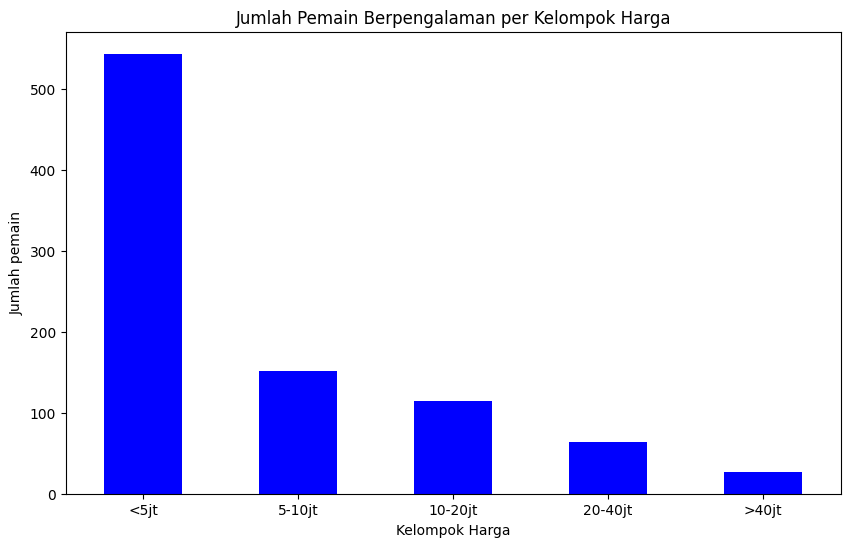


Mean   : 8.79 juta euro
Median : 4.0 juta euro
Std    : 13.76 juta euro
Batas atas wajar (IQR): 22.3 juta euro
Jumlah outlier (super mahal): 77


In [92]:

# ringkasan statistik market value pemain >=28
print(df_28['value_juta'].describe())

# bagi market value ke kelompok harga yang kebaca
batas = [0, 5, 10, 20, 40, df_28['value_juta'].max()]
label = ['<5jt', '5-10jt', '10-20jt', '20-40jt', '>40jt']
df_28['kelompok_value'] = pd.cut(df_28['value_juta'], bins=batas, labels=label)

# hitung jumlah pemain per kelompok harga
jumlah_per_kelompok = df_28['kelompok_value'].value_counts().sort_index()

jumlah_per_kelompok.plot(kind='bar', figsize=(10, 6), color='blue',
                         title='Jumlah Pemain Berpengalaman per Kelompok Harga')
plt.xlabel('Kelompok Harga'); plt.ylabel('Jumlah pemain')
plt.xticks(rotation=0)
plt.show()

# deteksi outlier pakai metode IQR
Q1 = df_28['value_juta'].quantile(0.25)
Q3 = df_28['value_juta'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
outlier = df_28[df_28['value_juta'] > batas_atas]

print('\nMean   :', round(df_28['value_juta'].mean(), 2), 'juta euro')
print('Median :', round(df_28['value_juta'].median(), 2), 'juta euro')
print('Std    :', round(df_28['value_juta'].std(), 2), 'juta euro')
print('Batas atas wajar (IQR):', round(batas_atas, 2), 'juta euro')
print('Jumlah outlier (super mahal):', len(outlier))

**INSIGHT:** Mean market value pemain berpengalaman sekitar 8.79 Juta euro, sedangkan median hanya 4.0 Juta euro. karena mean lebih besar dari median, distribusinya miring ke kanan(right-skewed). terlihat juga dari bar chart yang tinggi menumpuk di kelompok harga murah lalu makin pendek di kelompok mahal. Artinya meyoritas pemain berpengalaman justru bernilai rendah, dan rata-rata tertarik ke atas oleh 77 pemain merupakan pemain outlier yang bernilai sangat tinggi. Bagi klub papan tengah, outlier mahal ini di luar jangkauan. fokus berburu sebainyua di sekitar std ke bawah yang paling padat kandidatnya.

#### 6. Statistik Inferensial : Apakah pemain >= 28 dihargai signifikan lebih murah?

In [73]:
"""
Gunanya : menguji secara statistik perbedaan market value pemain >=28 vs <28.
Alasan  : perbedaan yang terlihat di plot perlu dibuktikan signifikan secara statistik,
          bukan sekadar kebetulan; dipakai two-sample independent t-test.
Tujuan  : memberi dasar statistik bahwa pemain berpengalaman cenderung dihargai lebih murah.
"""
from scipy import stats

# pisahkan dua kelompok usia (pakai df penuh)
value_tua = df[df['age'] >= 28]['value_juta']
value_muda = df[df['age'] < 28]['value_juta']

# two-sample independent t-test (equal_var=False karena varians kedua kelompok beda)
t_stat, p_value = stats.ttest_ind(value_tua, value_muda, equal_var=False)

print('Rata-rata value pemain >=28 :', round(value_tua.mean(), 2), 'juta euro')
print('Rata-rata value pemain <28  :', round(value_muda.mean(), 2), 'juta euro')
print('t-statistic :', round(t_stat, 3))
print('p-value     :', p_value)

Rata-rata value pemain >=28 : 6.61 juta euro
Rata-rata value pemain <28  : 13.66 juta euro
t-statistic : -12.543
p-value     : 2.9675368602404584e-35


**Hipotesis:**

- **H0:** Tidak ada perbedaan rata-rata market value antara pemain >=28 dan < 28
- **H1:** Ada perbedaan rata-rata market value antara kedua kelompok

Hasil two-sample independet t-test menghasil p-value 2,97e-35 (jauh di bawah 0,05) sehingga kita menolak **H0**. Artinya perbedaan market value antara pemain berpengalaman dengan pemain muda signifikan secara statistik. Rata-rata pemain >= 28 tahun hanya bernilai 6.61 Juta euro, kurang dari separuh pemain muda yang mencapai 13,66 Juta euro. Hasil ini mendukung kuat latar belakang bahwa pemain berpengalaman cendrung dihargai jauh lebih murah meski belum tentu performanya menurun. inilah celah pasar yang bisa dimanfaatkan klub papan tengah.

In [76]:
df.to_csv('P0M1_cesar_rivaldo_dataset.csv', index=False)


### Conclusion

Analisis terhadap 899+ pemain aktif di 5 Liga top Eropa menghasilkan temuan berikut :

1. **Value menurun setelah usia 28.** Median market value memuncak di usia awal 20-an lalu turun konsisten setelahnya, mengkonfirmasi bahwa pemain berpengalaman terdiskon karena faktor usia, bukan semata-mata karena performa yang menurun. 

2. **Perbedaan harga terbukti signifikan.** Pemain >=28 tahun rata-rata bernilai 6,61 Juta Euro, kurang dari separuh pemain muda (13,66 Juta). Two-sample independent t-test memberi p-value 2,97e-35, jadi perbedaan ini signifikan secara statistik bukan kebetulan 

3. **Sebaran value miring ke kanan.** Mayoritas pemain berpengalaman bernilai lebih rendah (median hanya 4 juta euro, 75% dibawah 10juta), dengan segelintir outlier hingga 180 juta yang berada diluar jangkauan klub papan tengah 

4. **Pasar rasional, tapi ada pengecualian.** Secara rata-rata pemain mahal memang lebih produktif, namun ada individu di kelompok harga terjangkau dengan kontribusi tinggi, merekalah target undervalued yang dicari. 

**REKOMENDASI:** Sport Director sebaiknya memfokuskan rekrutmen pada pemain berpengalaman (>=28 thaun) di rentang harga menengah (sekitar median 4-10 juta), yang terbukti memberi kontribusi tinggi perjuta euro-mnya. Shortlist 15 pemain teratas (dipimpin : `Tolisso`) menjadi tiitk awal pencarian yang konkret.

**KETERBATASAN:** metrik value-for-money dihitung dari gol+assist, sehingga condong ke pemain penyerang dan midfield. untuk menilai secara adil untuk posisi bek dan kiper diperlukan metrik tambahan seperti cleensheet, tackle, intersep, dll. 